## Titanic Dataset — Feature Engineering Tutorial

# 1. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical transformations
from scipy import stats

# Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Encoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

%matplotlib inline

# 2. Load Dataset

In [4]:
# Load the Titanic dataset
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\ML\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Shape of the dataset (rows, columns)
df.shape

(891, 12)

In [6]:
# Column names
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [7]:
 # Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Missing values per column
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 3. Feature Transformation

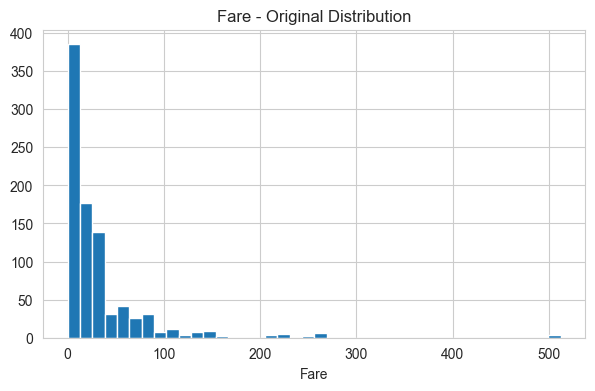

Original Fare skewness: 4.787316519674893


In [10]:
# Skewness rule of thumb:
# skew ~ 0            -> normal distribution
# skew < -1            -> negative (left) skew
# skew > +1            -> positive (right) skew
# -1 to 1 (roughly)    -> acceptably close to normal

fare = df[['Fare']].copy()
fare.hist(bins=40)
plt.title('Fare - Original Distribution')
plt.xlabel('Fare')
plt.show()
print("Original Fare skewness:", fare['Fare'].skew())


# 3.1 Root Transformation

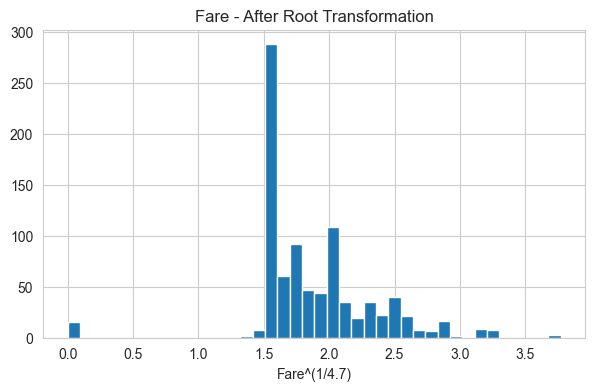

Root-transformed Fare skewness: 0.00982006067812734


In [11]:

# Root transformation: nth root compresses large values, pulling the tail in
fare['Fare_root'] = fare['Fare'] ** (1 / 4.7)
fare['Fare_root'].hist(bins=40)
plt.title('Fare - After Root Transformation')
plt.xlabel('Fare^(1/4.7)')
plt.show()
print("Root-transformed Fare skewness:", fare['Fare_root'].skew())

# 3.2 Logarithmic Transformation

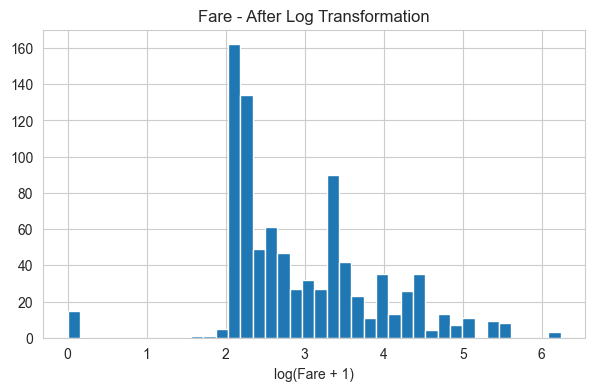

Log-transformed Fare skewness: 0.3949280095189306


In [12]:
# Log transformation (+1 to avoid log(0) = -inf)
fare['Fare_log'] = np.log(fare['Fare'] + 1)
fare['Fare_log'].hist(bins=40)
plt.title('Fare - After Log Transformation')
plt.xlabel('log(Fare + 1)')
plt.show()
print("Log-transformed Fare skewness:", fare['Fare_log'].skew())


# 3.3 Reciprocal Transformation

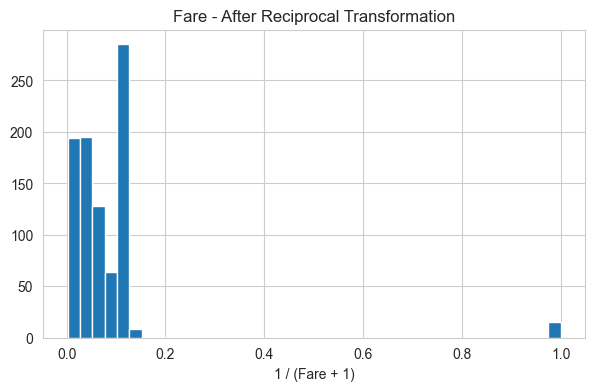

Reciprocal-transformed Fare skewness: 6.357430008713971


In [13]:
# Reciprocal transformation (+1 to avoid division by zero)
fare['Fare_reciprocal'] = 1 / (fare['Fare'] + 1)
fare['Fare_reciprocal'].hist(bins=40)
plt.title('Fare - After Reciprocal Transformation')
plt.xlabel('1 / (Fare + 1)')
plt.show()
print("Reciprocal-transformed Fare skewness:", fare['Fare_reciprocal'].skew())


# 3.4 Box-Cox Transformation

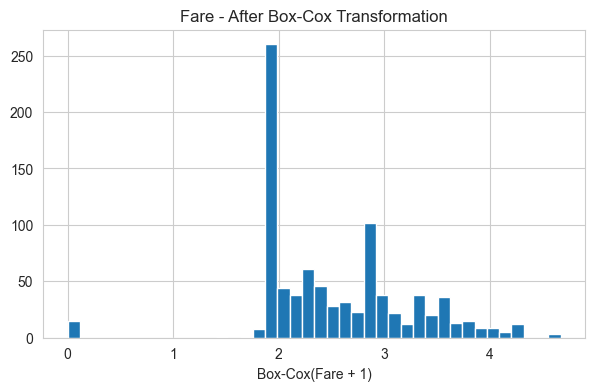

Box-Cox-transformed Fare skewness: -0.04032915137339973
Optimal lambda: -0.09778702173339403


In [14]:
# Box-Cox transformation - scipy finds the optimal lambda automatically
fare['Fare_boxcox'], best_lambda = stats.boxcox(fare['Fare'] + 1)
fare['Fare_boxcox'].hist(bins=40)
plt.title('Fare - After Box-Cox Transformation')
plt.xlabel('Box-Cox(Fare + 1)')
plt.show()
print("Box-Cox-transformed Fare skewness:", fare['Fare_boxcox'].skew())
print("Optimal lambda:", best_lambda)


# Comparison Table

In [15]:
# Compare skewness across all transformations
comparison = pd.DataFrame({
'Transformation': ['Original', 'Root', 'Log', 'Reciprocal', 'Box-Cox'],
'Skewness': [
fare['Fare'].skew(),
fare['Fare_root'].skew(),
fare['Fare_log'].skew(),
fare['Fare_reciprocal'].skew(),
fare['Fare_boxcox'].skew()
]
})
comparison['Abs_Skewness'] = comparison['Skewness'].abs()
comparison = comparison.sort_values('Abs_Skewness').reset_index(drop=True)
comparison


,Transformation,Skewness,Abs_Skewness
0,Root,0.009820,0.009820
1,Box-Cox,-0.040329,0.040329
2,Log,0.394928,0.394928
3,Original,4.787317,4.787317
4,Reciprocal,6.357430,6.357430


# 4. Feature Scaling

In [16]:
# Fill missing Age values using the median (robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())
# Confirm no missing values remain
df['Age'].isnull().sum()

np.int64(0)

# 4.1 StandardScaler

In [17]:
# StandardScaler
scaler_std = StandardScaler()
df['Age_standard'] = scaler_std.fit_transform(df[['Age']])
print("Age_standard - min:", df['Age_standard'].min(), " max:", df['Age_standard'].max())
df[['Age', 'Age_standard']].head()

Age_standard - min: -2.224156079948338  max: 3.8915544515600136


,Age,Age_standard
0,22.0,-0.565736
1,38.0,0.663861
2,26.0,-0.258337
3,35.0,0.433312
4,35.0,0.433312


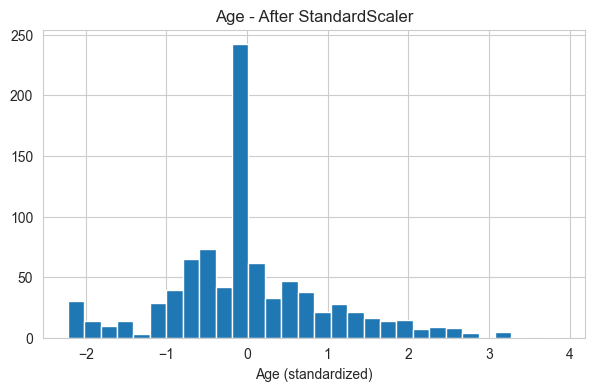

In [18]:
df['Age_standard'].hist(bins=30)
plt.title('Age - After StandardScaler')
plt.xlabel('Age (standardized)')
plt.show()


# 4.2 MinMaxScaler

In [19]:
# MinMaxScaler
scaler_mm = MinMaxScaler()
df['Age_minmax'] = scaler_mm.fit_transform(df[['Age']])
print("Age_minmax - min:", df['Age_minmax'].min(), " max:", df['Age_minmax'].max())
df[['Age', 'Age_minmax']].head()

Age_minmax - min: 0.0  max: 1.0


,Age,Age_minmax
0,22.0,0.271174
1,38.0,0.472229
2,26.0,0.321438
3,35.0,0.434531
4,35.0,0.434531


# 4.3 RobustScaler

In [21]:

# RobustScaler
scaler_rb = RobustScaler()
df['Age_robust'] = scaler_rb.fit_transform(df[['Age']])
print("Age_robust - min:", df['Age_robust'].min(), " max:", df['Age_robust'].max())
df[['Age', 'Age_robust']].head()

Age_robust - min: -2.1215384615384614  max: 4.0


,Age,Age_robust
0,22.0,-0.461538
1,38.0,0.769231
2,26.0,-0.153846
3,35.0,0.538462
4,35.0,0.538462


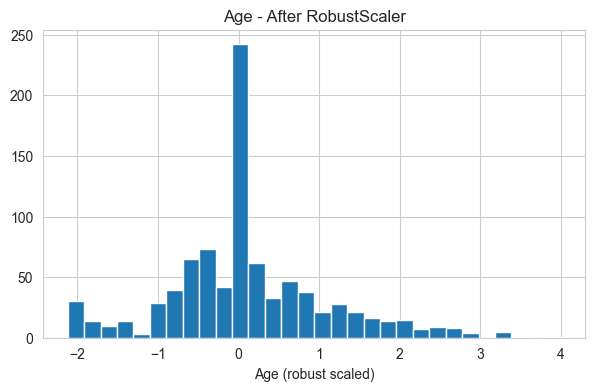

In [22]:
df['Age_robust'].hist(bins=30)
plt.title('Age - After RobustScaler')
plt.xlabel('Age (robust scaled)')
plt.show()

# 4.4 MaxAbsScaler

In [23]:
# MaxAbsScaler
scaler_ma = MaxAbsScaler()
df['Age_maxabs'] = scaler_ma.fit_transform(df[['Age']])
print("Age_maxabs - min:", df['Age_maxabs'].min(), " max:", df['Age_maxabs'].max())
df[['Age', 'Age_maxabs']].head()

Age_maxabs - min: 0.0052499999999999995  max: 1.0


,Age,Age_maxabs
0,22.0,0.2750
1,38.0,0.4750
2,26.0,0.3250
3,35.0,0.4375
4,35.0,0.4375


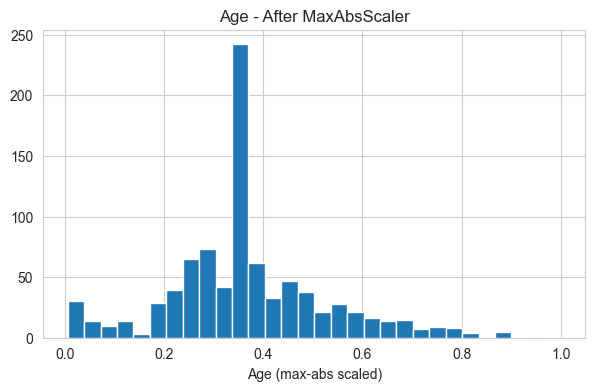

In [24]:

df['Age_maxabs'].hist(bins=30)
plt.title('Age - After MaxAbsScaler')
plt.xlabel('Age (max-abs scaled)')
plt.show()

# Comparison DataFrame

In [26]:

# All scalers side-by-side
scaling_comparison = df[['Age', 'Age_standard', 'Age_minmax', 'Age_robust', 'Age_maxabs']]
scaling_comparison.head(10)

,Age,Age_standard,Age_minmax,Age_robust,Age_maxabs
0,22.0,-0.565736,0.271174,-0.461538,0.2750
1,38.0,0.663861,0.472229,0.769231,0.4750
2,26.0,-0.258337,0.321438,-0.153846,0.3250
3,35.0,0.433312,0.434531,0.538462,0.4375
4,35.0,0.433312,0.434531,0.538462,0.4375
5,28.0,-0.104637,0.346569,0.000000,0.3500
6,54.0,1.893459,0.673285,2.000000,0.6750
7,2.0,-2.102733,0.019854,-2.000000,0.0250
8,27.0,-0.181487,0.334004,-0.076923,0.3375
9,14.0,-1.180535,0.170646,-1.076923,0.1750


# 5. Feature Encoding

# 5.1 pandas get_dummies()

In [27]:
# get_dummies on Sex and Embarked (nominal columns)
df_dummies = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=False)
df_dummies[[c for c in df_dummies.columns if 'Sex' in c or 'Embarked' in c]].head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,False,False,True
4,False,True,False,False,True


# 5.2 OneHotEncoder (sklearn)

In [28]:
# OneHotEncoder on the Embarked column
ohe = OneHotEncoder(sparse_output=False)
embarked_filled = df[['Embarked']].fillna(df['Embarked'].mode()[0])
ohe_array = ohe.fit_transform(embarked_filled)
# Convert to DataFrame with proper column names
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(['Embarked']))
ohe_df.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [32]:
# Merge encoded columns back with the original dataset
df_ohe_merged = pd.concat([df.reset_index(drop=True), ohe_df.reset_index(drop=True)])
df_ohe_merged.drop(columns=['Embarked'], inplace=True)
df_ohe_merged[['PassengerId', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head()

,PassengerId,Embarked_C,Embarked_Q,Embarked_S
0,1.0,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN
2,3.0,NaN,NaN,NaN
3,4.0,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN


# 5.3 LabelEncoder

In [33]:
# LabelEncoder - suitable here because Sex is binary (only 2 categories)
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
print("Classes:", le.classes_) # shows which label maps to which integer
df[['Sex', 'Sex_encoded']].head()

Classes: ['female' 'male']


,Sex,Sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


# 5.4 OrdinalEncoder

In [35]:
# Sample ordinal dataframe - Education level has a clear natural order
education_df = pd.DataFrame({'Education': ['Bachelor', 'High School', 'PhD', 'Master', 'High School', 'PhD']
})
# Specify the order explicitly so it's ranked correctly (not alphabetically)
ordinal_order = [['High School', 'Bachelor', 'Master', 'PhD']]
oe = OrdinalEncoder(categories=ordinal_order)
education_df['Education_encoded'] = oe.fit_transform(education_df[['Education']])
education_df

,Education,Education_encoded
0,Bachelor,1.0
1,High School,0.0
2,PhD,3.0
3,Master,2.0
4,High School,0.0
5,PhD,3.0


# 5.5 map() with a custom dictionary

In [36]:
# Custom mapping for Sex
df['Sex_mapped'] = df['Sex'].map({'male': 0, 'female': 1})
df[['Sex', 'Sex_mapped']].head()

,Sex,Sex_mapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


# 6. Discretization / Binning

In [37]:
# Define bin edges and labels for Age groups
bin_edges = [0, 12, 19, 35, 60, 90]
bin_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['Age_category'] = pd.cut(x=df['Age'], bins=bin_edges, labels=bin_labels)
df[['Age', 'Age_category']].head(10)

,Age,Age_category
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


C:\Users\User\AppData\Local\Temp\ipykernel_29008\1029470973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age_category', data=df, order=bin_labels, palette='viridis')


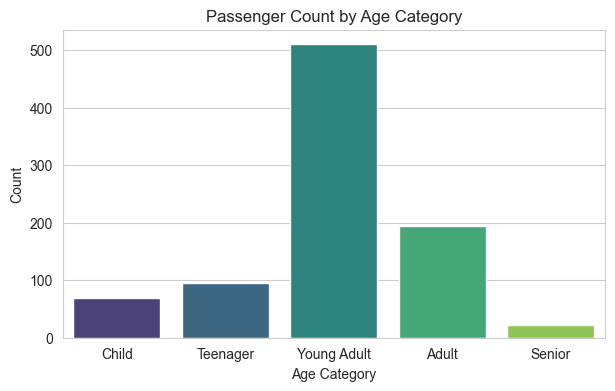

In [38]:
# Countplot of the binned age categories
plt.figure(figsize=(7, 4))
sns.countplot(x='Age_category', data=df, order=bin_labels, palette='viridis')
plt.title('Passenger Count by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.show()

# 7. Train-Test Split

In [41]:
from sklearn.model_selection import train_test_split
# Select feature columns and the target
feature_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded']
X = df[feature_cols]
y = df['Survived']

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_encoded
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,0
2,3,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,0
4,3,35.0,0,0,8.0500,1


In [42]:
# Basic split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (712, 6)
X_test shape : (179, 6)
y_train shape: (712,)
y_test shape : (179,)


# Stratified Split

In [43]:
# Stratified split - preserves the Survived ratio in both sets
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)
print("Overall survival rate   :", round(y.mean(), 3))
print("Train survival rate     :", round(y_train_strat.mean(), 3))
print("Test survival rate      :", round(y_test_strat.mean(), 3))

Overall survival rate   : 0.384
Train survival rate     : 0.383
Test survival rate      : 0.385


In [44]:
# Visual comparison of class balance across the splits
split_balance = pd.DataFrame({
'Full Dataset': y.value_counts(normalize=True),
'Train (stratified)': y_train_strat.value_counts(normalize=True),
'Test (stratified)': y_test_strat.value_counts(normalize=True)
})
split_balance.index = ['Did Not Survive (0)', 'Survived (1)']
split_balance.round(3)

,Full Dataset,Train (stratified),Test (stratified)
Did Not Survive (0),0.616,0.617,0.615
Survived (1),0.384,0.383,0.385
